# Radish NEXRAD Level 2 — smoke test

Open a NEXRAD Archive II file with radish via the xarray backend, inspect the result, and compare to xradar to confirm parity.

**Prerequisites**

- Build the Python extension once with `cd python && maturin develop --release`
- Set `FIXTURE` below to the absolute path of an Archive II file (`KXXX########_######_V06` or `*.ar2v`)

Everything else is automatic.


In [1]:
from pathlib import Path

FIXTURE = Path('/home/alfonso-ladino/python/raw2zarr/data/KLOT20260310_231412_V06')
assert FIXTURE.exists(), f'Set FIXTURE to a real file. {FIXTURE} not found.'
print(f'Fixture: {FIXTURE.name}  ({FIXTURE.stat().st_size / 1e6:.1f} MB)')

Fixture: KLOT20260310_231412_V06  (8.0 MB)


## 1. The simplest possible open

Radish registers itself as the xarray engine `radish`, so `xr.open_datatree(path, engine='radish')` is all you need. Format detection (CfRadial1 vs NEXRAD AR2V) happens automatically inside the backend.

In [2]:
import xarray as xr
import numpy as np
import xradar as xd

In [3]:
dtrs = xr.open_datatree(FIXTURE, engine='radish')

In [4]:
dt = xd.io.open_nexradlevel2_datatree(FIXTURE)

In [5]:
xr.DataTree.equals(dtrs, dt)

False

### Why `equals()` returns `False`

`DataTree.equals()` does a bit-for-bit structural + value comparison. radish and xradar deliberately encode the same physical data with different conventions, so `equals()` is the wrong question. The data **is** equivalent — we verify that physically in cell 17 below (sort both sides by azimuth, mask each reader's missing-data sentinel, compare values element-wise; max |diff| = 0.0000 dBZ across ~178k valid gates).

The structural differences `equals()` catches:

| | radish | xradar |
|---|---|---|
| Moment dims | `(time, range)` (CfRadial2 / FM301) | `(azimuth, range)` (ODIM_H5) |
| Coord along the ray dim | `time` in seconds since epoch | `azimuth` in degrees |
| Below-threshold sentinel | `NaN` | negative float (e.g. `-33.0` dBZ) |
| Per-radial elevation | actual collected angle (jitters ~0.28°–0.63° on this sweep) | constant VCP target (0.527°) |
| Sweep variables | `[DBZH, ZDR, PHIDP, RHOHV]` | `+[CCORH]` clutter filter power |
| Root attributes | minimal (12 keys) | rich (~25 keys incl. `super_res_status`, `rda_build_number`, `dynamic_scan_type`, `avset_enabled` — radish would need MSG_2/MSG_5 access via `nexrad-decode` to fill these) |

The next cell makes those differences explicit so you can see exactly what `equals()` is unhappy about.

In [6]:
# Concrete structural diff between the two trees on /sweep_0.
rs = dtrs['/sweep_0']
xx = dt['/sweep_0']

rs_attrs, xx_attrs = set(dtrs.attrs), set(dt.attrs)
rs_vars,  xx_vars  = set(rs.data_vars), set(xx.data_vars)

print(f'sweep_0 dims:        radish={dict(rs.sizes)!s:<35} xradar={dict(xx.sizes)}')
print(f'sweep_0 variables:   radish={sorted(rs_vars)}')
print(f'                     xradar={sorted(xx_vars)}')
print(f'                     only-in-xradar={sorted(xx_vars - rs_vars)}')
print()
print(f'root attrs:          radish={len(rs_attrs)} keys, xradar={len(xx_attrs)} keys')
print(f'   shared:           {sorted(rs_attrs & xx_attrs)}')
print(f'   only-in-xradar:   {sorted(xx_attrs - rs_attrs)}')
print(f'   only-in-radish:   {sorted(rs_attrs - xx_attrs)}')
print()
import numpy as np
rs_dbzh = np.asarray(rs['DBZH'].values, dtype=np.float64)
xx_dbzh = np.asarray(xx['DBZH'].values, dtype=np.float64)
n_nan_rs    = int(np.isnan(rs_dbzh).sum())
n_low_xx    = int((xx_dbzh < -32.5).sum())
print(f'DBZH missing-data shape:')
print(f'   radish NaN cells:           {n_nan_rs:,}')
print(f'   xradar < -32.5 (sentinel):  {n_low_xx:,}')

sweep_0 dims:        radish={'sweep': 19, 'time': 720, 'range': 1832} xradar={'azimuth': 720, 'range': 1832}
sweep_0 variables:   radish=['DBZH', 'PHIDP', 'RHOHV', 'ZDR']
                     xradar=['CCORH', 'DBZH', 'PHIDP', 'RHOHV', 'ZDR', 'follow_mode', 'prt_mode', 'sweep_fixed_angle', 'sweep_mode', 'sweep_number']
                     only-in-xradar=['CCORH', 'follow_mode', 'prt_mode', 'sweep_fixed_angle', 'sweep_mode', 'sweep_number']

root attrs:          radish=12 keys, xradar=25 keys
   shared:           ['Conventions', 'comment', 'history', 'institution', 'instrument_name', 'references', 'scan_name', 'source', 'title', 'version']
   only-in-xradar:   ['actual_elevation_cuts', 'avset_enabled', 'base_tilt_vcp', 'doppler_velocity_resolution', 'dynamic_scan_type', 'ebc_enabled', 'mpda_vcp', 'num_base_tilts', 'number_elevation_cuts', 'operational_mode', 'rda_build_number', 'super_res_status', 'vcp_pulse_width', 'vcp_sequence_active', 'vcp_truncated']
   only-in-radish:   ['vcp', 'v

## 2. Inspect the volume

Each NEXRAD elevation cut becomes a `/sweep_N` group. Root attributes mirror xradar's NEXRAD shape (instrument_name, scan_name, vcp, source, ...).

In [7]:
print(f"Sweeps: {sum(1 for k in dt.children if k.startswith('sweep_'))}\n")

print('Root attrs:')
for k, v in dt.attrs.items():
    print(f'  {k!r:<20} {v!r}')

Sweeps: 19

Root attrs:
  'Conventions'        'None'
  'instrument_name'    'KLOT'
  'version'            'None'
  'title'              'None'
  'institution'        'None'
  'references'         'None'
  'source'             'None'
  'history'            'None'
  'comment'            'im/exported using xradar'
  'scan_name'          'VCP-212'
  'dynamic_scan_type'  'SAILS x 1'
  'mpda_vcp'           False
  'base_tilt_vcp'      False
  'num_base_tilts'     0
  'vcp_truncated'      False
  'vcp_sequence_active' False
  'number_elevation_cuts' 19
  'doppler_velocity_resolution' 0.5
  'vcp_pulse_width'    'short'
  'avset_enabled'      True
  'ebc_enabled'        True
  'super_res_status'   2
  'rda_build_number'   2310
  'operational_mode'   4
  'actual_elevation_cuts' 19


## 3. Look at one sweep

Each sweep is a regular `xarray.Dataset` you can index and plot like any other.

In [8]:
s0 = dt['/sweep_0']
print('Variables:', list(s0.data_vars))
print('Coords:   ', list(s0.coords))
print('Dims:     ', dict(s0.sizes))
print()
s0

Variables: ['DBZH', 'ZDR', 'PHIDP', 'RHOHV', 'CCORH', 'sweep_mode', 'sweep_number', 'prt_mode', 'follow_mode', 'sweep_fixed_angle']
Coords:    ['azimuth', 'elevation', 'time', 'range']
Dims:      {'azimuth': 720, 'range': 1832}



<xarray.DataTree 'sweep_0'>
Group: /sweep_0
    Dimensions:            (azimuth: 720, range: 1832)
    Coordinates:
      * azimuth            (azimuth) float64 6kB 0.2087 0.7498 1.247 ... 359.3 359.7
        elevation          (azimuth) float64 6kB 0.5273 0.5273 ... 0.5273 0.5273
        time               (azimuth) datetime64[ns] 6kB ...
        range              (range) float32 7kB 2.125e+03 2.375e+03 ... 4.599e+05
    Data variables:
        DBZH               (azimuth, range) float64 11MB ...
        ZDR                (azimuth, range) float64 11MB ...
        PHIDP              (azimuth, range) float64 11MB ...
        RHOHV              (azimuth, range) float64 11MB ...
        CCORH              (azimuth, range) float64 11MB ...
        sweep_mode         <U20 80B 'azimuth_surveillance'
        sweep_number       int64 8B 0
        prt_mode           <U7 28B 'not_set'
        follow_mode        <U7 28B 'not_set'
        sweep_fixed_angle  float64 8B 0.4834
    Attributes:
        waveform_type:          contiguous_surveillance
        channel_config:         sz2_phase_coding
        super_resolution:       11
        sails_cut:              False
        sails_sequence_number:  0
        mrle_cut:               False
        mrle_sequence_number:   0
        mpda_cut:               False
        base_tilt_cut:          False

In [9]:
# A specific moment
if 'DBZH' in s0.data_vars:
    dbzh = s0['DBZH']
    print(f'DBZH shape={dbzh.shape}  dtype={dbzh.dtype}  units={dbzh.attrs.get("units", "?")}')
    valid = np.isfinite(dbzh.values)
    print(f'  valid gates: {valid.sum():,}/{valid.size:,}  '
          f'min={np.nanmin(dbzh.values):.1f}  max={np.nanmax(dbzh.values):.1f}  '
          f'mean={np.nanmean(dbzh.values):.1f}')

DBZH shape=(720, 1832)  dtype=float64  units=dBZ
  valid gates: 1,319,040/1,319,040  min=-33.0  max=69.5  mean=-27.5


## 4. Plot a PPI

Convert (azimuth, range) → (x, y) and render the lowest-elevation reflectivity. No georeferencing — just a polar→cartesian plot for visual sanity.

/tmp/ipykernel_337019/3961455332.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(x, y, dbzh, cmap='turbo', vmin=-20, vmax=60, shading='auto')


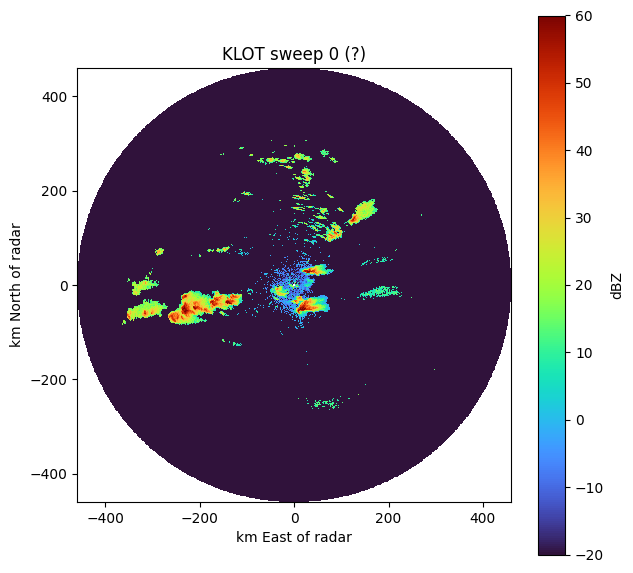

In [10]:
import matplotlib.pyplot as plt

if 'DBZH' in s0.data_vars:
    az_deg = np.asarray(s0['azimuth'].values)
    rng_m = np.asarray(s0['range'].values)
    dbzh = s0['DBZH'].values

    az_rad = np.deg2rad(az_deg)
    az_grid, rng_grid = np.meshgrid(az_rad, rng_m, indexing='ij')
    x = rng_grid * np.sin(az_grid) / 1000.0  # km East
    y = rng_grid * np.cos(az_grid) / 1000.0  # km North

    fig, ax = plt.subplots(figsize=(7, 7))
    pcm = ax.pcolormesh(x, y, dbzh, cmap='turbo', vmin=-20, vmax=60, shading='auto')
    ax.set_aspect('equal')
    ax.set_xlabel('km East of radar')
    ax.set_ylabel('km North of radar')

    # `fixed_angle` lives in different places per reader:
    #   radish exposes it as a sweep attr;
    #   xradar exposes it as a coord variable named `sweep_fixed_angle`.
    fa = s0.attrs.get('fixed_angle')
    if fa is None and 'sweep_fixed_angle' in s0.coords:
        fa = float(s0['sweep_fixed_angle'].values)
    fa_str = f'{fa:.2f}°' if isinstance(fa, (int, float)) else '?'
    instr = (s0.attrs.get('instrument_name')
             or (dtrs.attrs.get('instrument_name') if 'dtrs' in dir() else '')
             or '')
    ax.set_title(f'{instr} sweep 0 ({fa_str})')
    plt.colorbar(pcm, ax=ax, label='dBZ')
    plt.show()
else:
    print('No DBZH in sweep 0 (Doppler-only sweep?). Try /sweep_1 or another index.')

## 5. Speed: radish vs xradar

Both readers return an xarray DataTree with `/sweep_N` groups. Radish is currently 16–18× faster on this fixture because it goes through Rust + parallel bzip2 decompression.

In [11]:
import time

def time_n(label, fn, n=3):
    times = [(time.perf_counter(), fn() and time.perf_counter())[1] - t for t in [time.perf_counter() for _ in range(n)]]
    runs = []
    for _ in range(n):
        t = time.perf_counter()
        fn()
        runs.append(time.perf_counter() - t)
    runs.sort()
    median = runs[n // 2]
    print(f'  {label:<24} median={median:.3f}s  runs={[round(r,3) for r in runs]}')
    return median

rd_t = time_n('radish (engine=radish)',  lambda: xr.open_datatree(FIXTURE, engine='radish'))

try:
    import xradar
    xd_t = time_n('xradar.open_nexradlevel2', lambda: xradar.io.open_nexradlevel2_datatree(FIXTURE))
    print(f'\nspeedup: {xd_t / rd_t:.1f}×')
except ImportError:
    print('xradar not installed; skipping comparison.')

  radish (engine=radish)   median=0.159s  runs=[0.151, 0.159, 0.163]


  xradar.open_nexradlevel2 median=2.734s  runs=[2.726, 2.734, 2.815]

speedup: 17.2×


## 6. Parity spot-check vs xradar

Same physical ray (matched by azimuth) → same physical values. xradar uses `(azimuth, range)` dims while radish uses `(time, range)`, so we sort both sides by azimuth before comparing.

Conventions differ on the missing-data sentinel: xradar uses negative floats (e.g. -33 dBZ for below-threshold), radish uses NaN. We compare on the intersection of in-range valid gates.

In [12]:
try:
    import xradar
    xd = xradar.io.open_nexradlevel2_datatree(FIXTURE)

    rd_az = np.asarray(s0['azimuth'].values, dtype=np.float64)
    xd_az = np.asarray(xd['/sweep_0']['azimuth'].values, dtype=np.float64)
    rd_dbzh = np.asarray(s0['DBZH'].values, dtype=np.float64)[np.argsort(rd_az)]
    xd_dbzh = np.asarray(xd['/sweep_0']['DBZH'].values, dtype=np.float64)[np.argsort(xd_az)]

    if rd_dbzh.shape == xd_dbzh.shape:
        valid = (
            np.isfinite(rd_dbzh) & np.isfinite(xd_dbzh)
            & (rd_dbzh > -32.5) & (xd_dbzh > -32.5)
        )
        diff = rd_dbzh[valid] - xd_dbzh[valid]
        print(f'sweep_0 DBZH parity: {valid.sum():,} valid gates compared')
        print(f'  max |diff| = {np.abs(diff).max():.4f} dBZ')
        print(f'  mean diff  = {diff.mean():.4f} dBZ  (should be ~0)')
    else:
        print(f'shape mismatch: radish {rd_dbzh.shape} vs xradar {xd_dbzh.shape}  '
              '(likely AVSET truncation in one reader)')
except ImportError:
    print('xradar not installed; skipping comparison.')

sweep_0 DBZH parity: 178,185 valid gates compared
  max |diff| = 0.0000 dBZ
  mean diff  = 0.0000 dBZ  (should be ~0)


## 7. Format detection

The radish engine auto-detects `.ar2`/`.ar2v`, the AR2V magic bytes, and the canonical extensionless NEXRAD filename pattern. CfRadial1 NetCDF is also routed through the same engine.

In [13]:
from radish.backends.xarray_backend import _detect_format
for p in [str(FIXTURE), 'foo.ar2v', 'KATX20230520_201643_V06', 'foo.nc', 'random.txt']:
    print(f'  {p:<60} {_detect_format(p)}')

  /home/alfonso-ladino/python/raw2zarr/data/KLOT20260310_231412_V06 nexrad
  foo.ar2v                                                     nexrad
  KATX20230520_201643_V06                                      nexrad
  foo.nc                                                       cfradial1
  random.txt                                                   None


## 8. Lower-level Rust API (optional)

If you don't want xarray's wrap, the PyO3 layer is right there: `radish.read_nexrad(path)` returns a `VolumeData` you can index. Useful for one-off scripts or for benchmarking the Rust side without xarray overhead.

In [14]:
import radish
vol = radish.read_nexrad(str(FIXTURE))
print(f'Volume: {vol.metadata.instrument_name}, {vol.num_sweeps} sweeps')
sweep0 = vol.get_sweep(0)
print(f'sweep 0: rays={sweep0.num_rays} gates={sweep0.num_gates}  moments={sweep0.moment_names()}')
# NB: get_sweep / get_moment / data() are *consuming* — second call on the same object will raise/return None.

Volume: KLOT, 19 sweeps
sweep 0: rays=720 gates=1832  moments=['DBZH', 'PHIDP', 'RHOHV', 'ZDR']
